In [7]:
import re
import math
import requests
import random
from collections import Counter
from bs4 import BeautifulSoup

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [8]:
import requests

url = "https://www.gutenberg.org/files/1342/1342-0.txt"
text = requests.get(url).text

print(text[:2000])
print("Total characters:", len(text))

*** START OF THE PROJECT GUTENBERG EBOOK 1342 ***




                            [Illustration:

                             GEORGE ALLEN
                               PUBLISHER

                        156 CHARING CROSS ROAD
                                LONDON

                             RUSKIN HOUSE
                                   ]

                            [Illustration:

               _Reading Jane’s Letters._      _Chap 34._
                                   ]




                                PRIDE.
                                  and
                               PREJUDICE

                                  by
                             Jane Austen,

                           with a Preface by
                           George Saintsbury
                                  and
                           Illustrations by
                             Hugh Thomson

                         [Illustration: 1894]

                       Ruskin       156. Charing

In [9]:
def strip_gutenberg_header_footer(text: str) -> str:
    start_marker = "*** START OF THE PROJECT GUTENBERG EBOOK"
    end_marker = "*** END OF THE PROJECT GUTENBERG EBOOK"

    start_idx = text.find(start_marker)
    end_idx = text.find(end_marker)

    if start_idx != -1:
        text = text[start_idx:]
        first_newline = text.find("\n")
        text = text[first_newline + 1:]
    if end_idx != -1:
        text = text[:end_idx]
    return text

text = strip_gutenberg_header_footer(text)
text = text.lower()

# Простая токенизация: слова + знаки препинания
tokens = re.findall(r"\w+|[^\w\s]", text, re.UNICODE)

print(tokens[:50])
print("Number of tokens:", len(tokens))
print("Number of unique raw tokens:", len(set(tokens)))

['[', 'illustration', ':', 'george', 'allen', 'publisher', '156', 'charing', 'cross', 'road', 'london', 'ruskin', 'house', ']', '[', 'illustration', ':', '_reading', 'jane', '’', 's', 'letters', '.', '_', '_chap', '34', '.', '_', ']', 'pride', '.', 'and', 'prejudice', 'by', 'jane', 'austen', ',', 'with', 'a', 'preface', 'by', 'george', 'saintsbury', 'and', 'illustrations', 'by', 'hugh', 'thomson', '[', 'illustration']
Number of tokens: 154414
Number of unique raw tokens: 7052


In [10]:
MAX_TOKENS = 500_000     # можно увеличить до 100_000 или больше
MAX_VOCAB = 5000

tokens = tokens[:MAX_TOKENS]
print("Using tokens:", len(tokens))

counter = Counter(tokens)
most_common = counter.most_common(MAX_VOCAB - 2)  # reserving <pad>, <unk>

itos = ["<pad>", "<unk>"] + [w for w, _ in most_common]
stoi = {w: i for i, w in enumerate(itos)}

PAD_ID = stoi["<pad>"]
UNK_ID = stoi["<unk>"]

def encode_token(tok):
    return stoi.get(tok, UNK_ID)

ids = [encode_token(tok) for tok in tokens]

print("Vocab size:", len(itos))
print("First 30 ids:", ids[:30])

Using tokens: 154414
Vocab size: 5000
First 30 ids: [112, 125, 84, 359, 429, 4219, 2572, 3184, 1700, 860, 300, 3185, 165, 113, 112, 125, 84, 4220, 79, 35, 39, 821, 3, 316, 4221, 4222, 3, 316, 113, 317]


In [11]:
SEQ_LEN = 30
TRAIN_FRAC = 0.9
BATCH_SIZE = 32

class LanguageModelingDataset(Dataset):
    def __init__(self, ids, seq_len):
        self.ids = ids
        self.seq_len = seq_len

    def __len__(self):
        return len(self.ids) - self.seq_len

    def __getitem__(self, idx):
        x = torch.tensor(self.ids[idx: idx+ self.seq_len], dtype=torch.long)
        y = torch.tensor(self.ids[idx + 1: idx + self.seq_len + 1], dtype=torch.long)
        return x, y

split_idx = int(len(ids) * TRAIN_FRAC)
train_ids = ids[:split_idx]
test_ids = ids[split_idx:]

train_dataset = LanguageModelingDataset(train_ids, SEQ_LEN)
test_dataset = LanguageModelingDataset(test_ids, SEQ_LEN)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False
)

print("Train tokens:", len(train_ids))
print("Test tokens:", len(test_ids))
print("Train examples:", len(train_dataset))
print("Test examples:", len(test_dataset))

xb, yb = next(iter(train_loader))
print("xb shape:", xb.shape)
print("yb shape:", yb.shape)

Train tokens: 138972
Test tokens: 15442
Train examples: 138942
Test examples: 15412
xb shape: torch.Size([32, 30])
yb shape: torch.Size([32, 30])


## Shapes in the model

- input ids: `(batch_size, seq_len)`
- embeddings: `(batch_size, seq_len, emb_dim)`
- RNN hidden states: `(batch_size, seq_len, hidden_dim)`
- output logits: `(batch_size, seq_len, vocab_size)`

На каждом шаге модель предсказывает распределение по всему словарю.

In [12]:
class WordRNN(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim)
        self.rnn = nn.RNN(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )
        self.out = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, h0=None):
        # x: (B, L)
        x = self.emb(x)          # (B, L, E)
        h, h_n = self.rnn(x, h0) # h: (B, L, H)
        logits = self.out(h)     # (B, L, V)
        return logits, h_n

In [13]:
class WordLSTM(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim)
        self.rnn = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )
        self.out = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, state=None):
        x = self.emb(x)
        h, state = self.rnn(x, state)
        logits = self.out(h)
        return logits, state

In [14]:
VOCAB_SIZE = len(itos)
EMB_DIM = 16
HIDDEN_DIM = 16

model = WordRNN(VOCAB_SIZE, EMB_DIM, HIDDEN_DIM).to(device)
model

WordRNN(
  (emb): Embedding(5000, 16)
  (rnn): RNN(16, 16, batch_first=True)
  (out): Linear(in_features=16, out_features=5000, bias=True)
)

In [15]:
VOCAB_SIZE = len(itos)
EMB_DIM = 16
HIDDEN_DIM = 16

model = WordLSTM(VOCAB_SIZE, EMB_DIM, HIDDEN_DIM).to(device)
model

WordLSTM(
  (emb): Embedding(5000, 16)
  (rnn): LSTM(16, 16, batch_first=True)
  (out): Linear(in_features=16, out_features=5000, bias=True)
)

In [16]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [17]:
xb, yb = next(iter(train_loader))
xb = xb.to(device)
yb = yb.to(device)

logits, h_n = model(xb)

print("logits shape:", logits.shape)  # (B, L, V)
#print("h_n shape:", h_n.shape)        # (1, B, H)

loss = criterion(logits.reshape(-1, VOCAB_SIZE), yb.reshape(-1))
print("loss:", float(loss))

logits shape: torch.Size([32, 30, 5000])
loss: 8.552385330200195


In [18]:
@torch.no_grad()
def evaluate(model, loader, criterion, device, vocab_size):
    model.eval()
    total_loss = 0.0
    total_batches = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits, _ = model(xb)
        loss = criterion(logits.reshape(-1, vocab_size), yb.reshape(-1))

        total_loss += loss.item()
        total_batches += 1

    mean_loss = total_loss / total_batches
    ppl = math.exp(mean_loss)
    return mean_loss, ppl


EPOCHS = 10

train_losses = []
test_losses = []
train_ppls = []
test_ppls = []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits, _ = model(xb)
        loss = criterion(logits.reshape(-1, VOCAB_SIZE), yb.reshape(-1))
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_ppl = math.exp(train_loss)

    test_loss, test_ppl = evaluate(model, test_loader, criterion, device, VOCAB_SIZE)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_ppls.append(train_ppl)
    test_ppls.append(test_ppl)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"train loss = {train_loss:.4f} | train ppl = {train_ppl:.2f} | "
        f"test loss = {test_loss:.4f} | test ppl = {test_ppl:.2f}"
    )

Epoch 1/10 | train loss = 6.5294 | train ppl = 685.01 | test loss = 5.9746 | test ppl = 393.30
Epoch 2/10 | train loss = 5.9480 | train ppl = 382.97 | test loss = 5.9008 | test ppl = 365.33
Epoch 3/10 | train loss = 5.8431 | train ppl = 344.84 | test loss = 5.7697 | test ppl = 320.46
Epoch 4/10 | train loss = 5.6905 | train ppl = 296.05 | test loss = 5.6293 | test ppl = 278.46
Epoch 5/10 | train loss = 5.5537 | train ppl = 258.20 | test loss = 5.5273 | test ppl = 251.47
Epoch 6/10 | train loss = 5.4490 | train ppl = 232.52 | test loss = 5.4522 | test ppl = 233.26
Epoch 7/10 | train loss = 5.3592 | train ppl = 212.55 | test loss = 5.3847 | test ppl = 218.04
Epoch 8/10 | train loss = 5.2798 | train ppl = 196.33 | test loss = 5.3289 | test ppl = 206.21
Epoch 9/10 | train loss = 5.2039 | train ppl = 181.97 | test loss = 5.2678 | test ppl = 193.99
Epoch 10/10 | train loss = 5.1316 | train ppl = 169.29 | test loss = 5.2220 | test ppl = 185.31


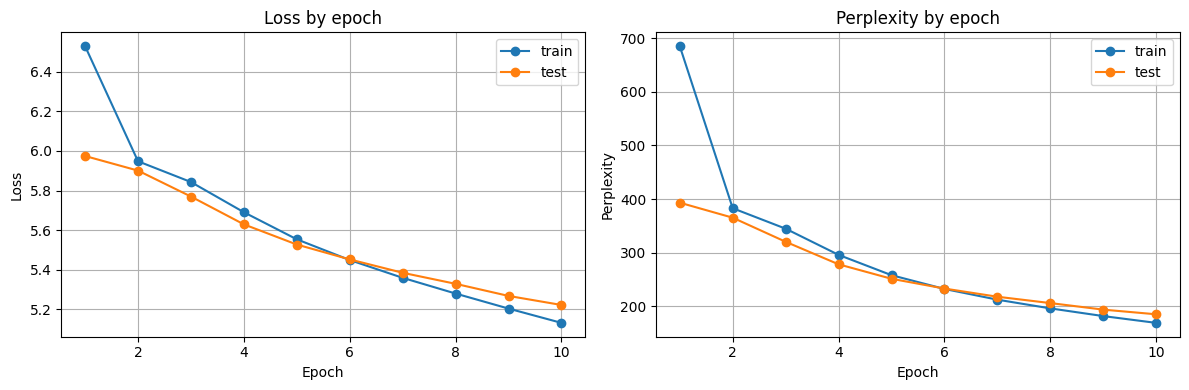

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, len(train_losses) + 1), train_losses, marker="o", label="train")
axes[0].plot(range(1, len(test_losses) + 1), test_losses, marker="o", label="test")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss by epoch")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(range(1, len(train_ppls) + 1), train_ppls, marker="o", label="train")
axes[1].plot(range(1, len(test_ppls) + 1), test_ppls, marker="o", label="test")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Perplexity")
axes[1].set_title("Perplexity by epoch")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

In [20]:
def decode_ids(id_list):
    return " ".join(itos[i] for i in id_list)

def sample_from_logits(logits, method="greedy", temperature=1.0, top_k=None):
    """
    logits: tensor of shape (V,)
    """
    logits = logits.detach().cpu()

    if method == "greedy":
        return int(torch.argmax(logits).item())

    # temperature
    logits = logits / temperature

    # top-k
    if top_k is not None:
        values, indices = torch.topk(logits, k=min(top_k, logits.shape[0]))
        probs = torch.softmax(values, dim=0)
        chosen = torch.multinomial(probs, num_samples=1).item()
        return int(indices[chosen].item())

    # plain sampling
    probs = torch.softmax(logits, dim=0)
    return int(torch.multinomial(probs, num_samples=1).item())

In [21]:
@torch.no_grad()
def generate_text(
    model,
    prompt,
    max_new_tokens=30,
    method="greedy",
    temperature=1.0,
    top_k=None
):
    model.eval()

    prompt_tokens = re.findall(r"\w+|[^\w\s]", prompt.lower(), re.UNICODE)
    if len(prompt_tokens) == 0:
        raise ValueError("Prompt is empty after tokenization.")

    input_ids = [stoi.get(tok, UNK_ID) for tok in prompt_tokens]
    generated = input_ids[:]

    # Сначала прогоняем весь prompt, чтобы получить состояние
    x = torch.tensor([generated], dtype=torch.long, device=device)
    logits, h = model(x)

    # Последний логит соответствует предсказанию после последнего токена prompt
    next_logits = logits[0, -1]

    for _ in range(max_new_tokens):
        next_id = sample_from_logits(
            next_logits,
            method=method,
            temperature=temperature,
            top_k=top_k
        )
        generated.append(next_id)

        # Следующий шаг: подаём только последний токен и продолжаем с тем же hidden state
        x_next = torch.tensor([[next_id]], dtype=torch.long, device=device)
        logits, h = model(x_next, h)
        next_logits = logits[0, -1]

    return decode_ids(generated)

In [22]:
prompt = "it is a truth"
print(generate_text(model, prompt, max_new_tokens=40, method="greedy"))

it is a truth of the <unk> of the <unk> of the <unk> of the <unk> of the <unk> of the <unk> of the <unk> of the <unk> of the <unk> of the <unk> of the <unk> of the <unk> of the <unk> of


In [23]:
prompt = "she was not"
print(generate_text(model, prompt, max_new_tokens=40, method="sampling"))

she was not ; beyond a parted . “ elizabeth his seen , you do appear to jane , ” us ! ” his sister to evening for the day of the bad . and these keep mrs whose mr . it a


In [24]:
prompt = "she likes apples"
print(generate_text(model, prompt, max_new_tokens=40, method="sampling"))

she likes <unk> ; pray acquaintance which is to go to has write on they been side he as i am circumstances to call it on the pemberley sense , you is alive of relieve , her is this happy glad and from


In [25]:
prompt = "elizabeth was"
print(generate_text(model, prompt, max_new_tokens=40, method="sampling", top_k=10))

elizabeth was the very other . but i am <unk> in the very - - been the very , and a own the very of the other . “ ” but i - . the day with the very man , i


## Вопросы для анализа

1. Как меняется loss по эпохам?
2. Насколько осмысленным становится текст после обучения?
3. Чем greedy decoding отличается от sampling?
4. Как влияет temperature?
5. Что меняется при top-k?
6. Какие типичные ошибки делает модель?
   - повторы
   - обрыв фраз
   - неграмматичные продолжения
   - слишком короткая память

### Задание
1. Обучите word-level RNN language model на тексте Джейн Остин.
2. Постройте график training loss.
3. Сгенерируйте тексты:
   - greedy
   - sampling
   - sampling with temperature
   - sampling with top-k
4. Сравните качество генерации.
5. (Опционально) замените RNN на LSTM и сравните результаты.

# Домашняя работа

## Работа с текстовыми данными

### Загрузка текста

Для загрузки текста реализуем функцию, я выбрал простейший способ - загрузка текста с сайта https://lib.ru/. Реализуем функцию загрузки текста.

In [26]:
url = 'http://az.lib.ru/t/tolstoj_lew_nikolaewich/text_0080.shtml'

In [27]:
# Функция для универсальной загрузки текстов с lib.ru
def download_text(url: str) -> str:
    response = requests.get(url)
    encoding = response.apparent_encoding
    return response.content.decode(encoding=encoding)

In [28]:
try:
    text = download_text(url)
except Exception as e:
    print(f'Ошибка при загрузке текстак: {e}')

In [29]:
# Посмотрим первые 200 символов из текста, который удалось загрузить
text[:500]

'<html>\r\n<head>\r\n<title>Lib.ru/Классика: Толстой Лев Николаевич. Анна Каренина</title>\r\n</head>\r\n\r\n<body>\r\n\r\n\r\n<center>\r\n\r\n<h2><a href=/t/tolstoj_lew_nikolaewich/>Толстой Лев Николаевич</a><br>\r\nАнна Каренина</h2>\r\n\r\n<!------- Первый блок ссылок ------------->\r\n\r\n<small>\r\n\r\n<a href=/><font color="#555555" size=-1\r\n><b>Lib.ru/Классика:</b></font></a>\r\n\r\n<!------------ Кнопка регистрации -------->\r\n\n\n[<A HREF="/cgi-bin/login">Регистрация</A>]\n \n\r\n<!---------------------------------------->\r\n\r\n[<a h'

Текст загрузился успешно, но осталось много "мусора", html-теги и прочее, необходимо избавиться от него.

In [30]:
soup = BeautifulSoup(text, "html.parser")

In [31]:
cleaned_text = soup.get_text()

In [32]:
# Найдем маркер с которого начинается текст
cleaned_text[600:900]

'Анна Каренина \n\n\n\n\nМне отмщение, и аз воздам\n\n\n\n\nЧАСТЬ ПЕРВАЯ\n\n\n\n\nI \n\n\n\xa0\xa0 Все счастливые семьи похожи друг на друга, каждая несчастливая семья несчастлива по-своему. \n\xa0\xa0 Все смешалось в доме Облонских. Жена узнала, что муж был в связи с бывшею в их доме француженкою-гувернанткой, и объявила мужу, чт'

Маркер с которого начинается текст - "Мне отмщение, и аз воздам"

In [33]:
start_marker = "Мне отмщение, и аз воздам"
end_marker = "каждая минута ее -- не только не бессмысленна, как была прежде, но имеет несомненный смысл добра, который я властен вложить в нее!"

start_index = cleaned_text.find(start_marker)
end_index = cleaned_text.find(end_marker)


text = cleaned_text[start_index:end_index]

In [34]:
# Простая токенизация: слова + знаки препинания
text = text.lower()
tokens = re.findall(r"\w+|[^\w\s]", text, re.UNICODE)

print(tokens[:50])
print("Number of tokens:", len(tokens))
print("Number of unique raw tokens:", len(set(tokens)))

['мне', 'отмщение', ',', 'и', 'аз', 'воздам', 'часть', 'первая', 'i', 'все', 'счастливые', 'семьи', 'похожи', 'друг', 'на', 'друга', ',', 'каждая', 'несчастливая', 'семья', 'несчастлива', 'по', '-', 'своему', '.', 'все', 'смешалось', 'в', 'доме', 'облонских', '.', 'жена', 'узнала', ',', 'что', 'муж', 'был', 'в', 'связи', 'с', 'бывшею', 'в', 'их', 'доме', 'француженкою', '-', 'гувернанткой', ',', 'и', 'объявила']
Number of tokens: 361292
Number of unique raw tokens: 33359


In [35]:
MAX_TOKENS = 500_000     # можно увеличить до 100_000 или больше
MAX_VOCAB = 10000

tokens = tokens[:MAX_TOKENS]
print("Using tokens:", len(tokens))

counter = Counter(tokens)
most_common = counter.most_common(MAX_VOCAB - 2)  # reserving <pad>, <unk>

itos = ["<pad>", "<unk>"] + [w for w, _ in most_common]
stoi = {w: i for i, w in enumerate(itos)}

PAD_ID = stoi["<pad>"]
UNK_ID = stoi["<unk>"]

def encode_token(tok):
    return stoi.get(tok, UNK_ID)

ids = [encode_token(tok) for tok in tokens]

print("Vocab size:", len(itos))
print("First 30 ids:", ids[:30])

Using tokens: 361292
Vocab size: 10000
First 30 ids: [53, 1, 2, 5, 1, 1, 840, 1456, 2719, 22, 6987, 1962, 4563, 360, 10, 520, 2, 2720, 1, 3030, 2459, 37, 3, 405, 4, 22, 4564, 8, 558, 3416]


In [36]:
SEQ_LEN = 30
TRAIN_FRAC = 0.9
BATCH_SIZE = 32

class LanguageModelingDataset(Dataset):
    def __init__(self, ids, seq_len):
        self.ids = ids
        self.seq_len = seq_len

    def __len__(self):
        return len(self.ids) - self.seq_len

    def __getitem__(self, idx):
        x = torch.tensor(self.ids[idx: idx+ self.seq_len], dtype=torch.long)
        y = torch.tensor(self.ids[idx + 1: idx + self.seq_len + 1], dtype=torch.long)
        return x, y

split_idx = int(len(ids) * TRAIN_FRAC)
train_ids = ids[:split_idx]
test_ids = ids[split_idx:]

train_dataset = LanguageModelingDataset(train_ids, SEQ_LEN)
test_dataset = LanguageModelingDataset(test_ids, SEQ_LEN)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False
)

print("Train tokens:", len(train_ids))
print("Test tokens:", len(test_ids))
print("Train examples:", len(train_dataset))
print("Test examples:", len(test_dataset))

xb, yb = next(iter(train_loader))
print("xb shape:", xb.shape)
print("yb shape:", yb.shape)

Train tokens: 325162
Test tokens: 36130
Train examples: 325132
Test examples: 36100
xb shape: torch.Size([32, 30])
yb shape: torch.Size([32, 30])


In [37]:
class WordRNN(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim)
        self.rnn = nn.RNN(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )
        self.out = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, h0=None):
        # x: (B, L)
        x = self.emb(x)          # (B, L, E)
        h, h_n = self.rnn(x, h0) # h: (B, L, H)
        logits = self.out(h)     # (B, L, V)
        return logits, h_n

In [38]:
VOCAB_SIZE = len(itos)
EMB_DIM = 16
HIDDEN_DIM = 16

model = WordRNN(VOCAB_SIZE, EMB_DIM, HIDDEN_DIM).to(device)
model

WordRNN(
  (emb): Embedding(10000, 16)
  (rnn): RNN(16, 16, batch_first=True)
  (out): Linear(in_features=16, out_features=10000, bias=True)
)

In [39]:
VOCAB_SIZE = len(itos)
EMB_DIM = 16
HIDDEN_DIM = 16

model = WordLSTM(VOCAB_SIZE, EMB_DIM, HIDDEN_DIM).to(device)
model

WordLSTM(
  (emb): Embedding(10000, 16)
  (rnn): LSTM(16, 16, batch_first=True)
  (out): Linear(in_features=16, out_features=10000, bias=True)
)

In [40]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [41]:
VOCAB_SIZE = len(itos)
EPOCHS = 10
train_losses = []
train_ppls = []
test_losses = []
test_ppls = []


for epoch in range(EPOCHS):
    
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        #1. Данные на device
        xb = xb.to(device)
        yb = yb.to(device)
        #2. Обнуляем градиенты
        optimizer.zero_grad()
        #3. forward pass
        logits, h_n = model(xb)
        #4. loss
        loss = criterion(logits.reshape(-1, VOCAB_SIZE), yb.reshape(-1))
        #5. backward 
        loss.backward()
        #6. optimizer step
        optimizer.step()
        running_loss += loss.item()
    
    avg_loss = running_loss / len(train_loader)
    train_ppl = math.exp(avg_loss)
    test_loss, test_ppl = evaluate(model, test_loader, criterion, device, VOCAB_SIZE)
    train_losses.append(avg_loss)
    train_ppls.append(train_ppl)
    test_losses.append(test_loss)
    test_ppls.append(test_ppl)
    print(f"Epoch {epoch} | Train Loss: {avg_loss:.4f} | Test Loss: {test_loss:.4f} | PPL: {train_ppl:.1f}")

Epoch 0 | Train Loss: 6.2333 | Test Loss: 5.8522 | PPL: 509.4
Epoch 1 | Train Loss: 5.6990 | Test Loss: 5.6534 | PPL: 298.6
Epoch 2 | Train Loss: 5.4979 | Test Loss: 5.5152 | PPL: 244.2
Epoch 3 | Train Loss: 5.3760 | Test Loss: 5.4427 | PPL: 216.1
Epoch 4 | Train Loss: 5.2897 | Test Loss: 5.3937 | PPL: 198.3
Epoch 5 | Train Loss: 5.2240 | Test Loss: 5.3583 | PPL: 185.7
Epoch 6 | Train Loss: 5.1712 | Test Loss: 5.3327 | PPL: 176.1
Epoch 7 | Train Loss: 5.1276 | Test Loss: 5.3127 | PPL: 168.6
Epoch 8 | Train Loss: 5.0891 | Test Loss: 5.2955 | PPL: 162.2
Epoch 9 | Train Loss: 5.0516 | Test Loss: 5.2738 | PPL: 156.3


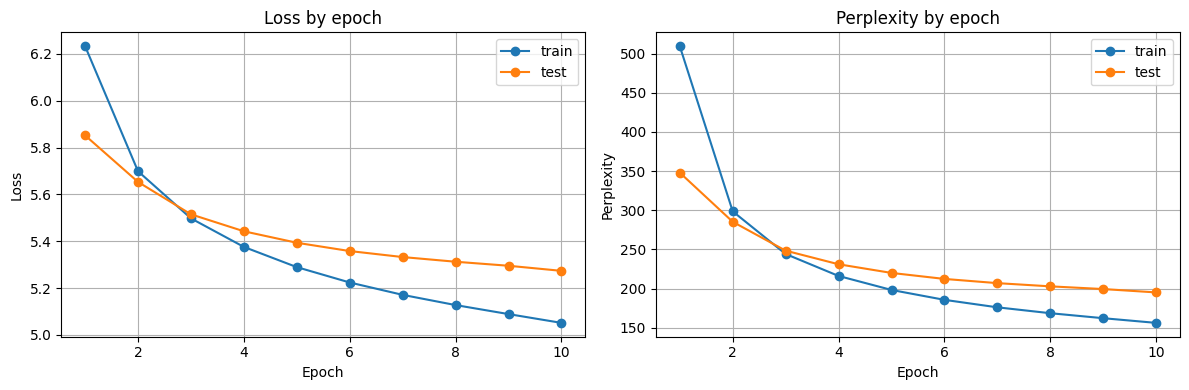

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, len(train_losses) + 1), train_losses, marker="o", label="train")
axes[0].plot(range(1, len(test_losses) + 1), test_losses, marker="o", label="test")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss by epoch")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(range(1, len(train_ppls) + 1), train_ppls, marker="o", label="train")
axes[1].plot(range(1, len(test_ppls) + 1), test_ppls, marker="o", label="test")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Perplexity")
axes[1].set_title("Perplexity by epoch")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

In [48]:
prompt = "все счастливые семьи"

In [49]:
print(generate_text(model, prompt, max_new_tokens=40, method="greedy"))

все счастливые семьи , что он , что он , что он , что он , что он , что он , что он , что он , что он , что он , что он , что он , что он ,


In [50]:
print(generate_text(model, prompt, max_new_tokens=40, method="sampling", top_k=10))

все счастливые семьи и , <unk> , - - <unk> , что он , что она в ее - - - то , <unk> , что . - - он чувствовал , - - да , а она , что , и не


In [51]:
print(generate_text(model, prompt, max_new_tokens=40, method="sampling", temperature=0.5))

все счастливые семьи . - - сказал она , что он <unk> , что он , - - сказала она как не <unk> , чтоб он было <unk> , что что , что она не <unk> , не <unk> , что не <unk>


In [ ]:
print(generate_text(model, prompt, max_new_tokens=40, method="sampling"))

все счастливые семьи , по смотрела прожить , и приходили платья личных своим солнце . он дурного учреждение и просто , либо , а лицо и думаем своим съезжу дать той всех приятели , и <unk> , у спасти рукав прежде , следили


In [65]:
VOCAB_SIZE = len(itos)
EMB_DIM = 16
HIDDEN_DIM = 16
model = WordLSTM(VOCAB_SIZE, EMB_DIM, HIDDEN_DIM).to(device)
model

WordLSTM(
  (emb): Embedding(10000, 16)
  (rnn): LSTM(16, 16, batch_first=True)
  (out): Linear(in_features=16, out_features=10000, bias=True)
)

In [66]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [67]:
EPOCHS = 10
train_losses = []
train_ppls = []
test_losses = []
test_ppls = []


for epoch in range(EPOCHS):
    
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        #1. Данные на device
        xb = xb.to(device)
        yb = yb.to(device)
        #2. Обнуляем градиенты
        optimizer.zero_grad()
        #3. forward pass
        logits, h_n = model(xb)
        #4. loss
        loss = criterion(logits.reshape(-1, VOCAB_SIZE), yb.reshape(-1))
        #5. backward 
        loss.backward()
        #6. optimizer step
        optimizer.step()
        running_loss += loss.item()
    
    avg_loss = running_loss / len(train_loader)
    train_ppl = math.exp(avg_loss)
    test_loss, test_ppl = evaluate(model, test_loader, criterion, device, VOCAB_SIZE)
    train_losses.append(avg_loss)
    train_ppls.append(train_ppl)
    test_losses.append(test_loss)
    test_ppls.append(test_ppl)
    print(f"Epoch {epoch} | Train Loss: {avg_loss:.4f} | Test Loss: {test_loss:.4f} | PPL: {train_ppl:.1f}")

Epoch 0 | Train Loss: 6.2059 | Test Loss: 5.8376 | PPL: 495.7
Epoch 1 | Train Loss: 5.6870 | Test Loss: 5.6389 | PPL: 295.0
Epoch 2 | Train Loss: 5.4741 | Test Loss: 5.4809 | PPL: 238.4
Epoch 3 | Train Loss: 5.3326 | Test Loss: 5.4034 | PPL: 207.0
Epoch 4 | Train Loss: 5.2443 | Test Loss: 5.3570 | PPL: 189.5
Epoch 5 | Train Loss: 5.1785 | Test Loss: 5.3237 | PPL: 177.4
Epoch 6 | Train Loss: 5.1259 | Test Loss: 5.3001 | PPL: 168.3
Epoch 7 | Train Loss: 5.0814 | Test Loss: 5.2811 | PPL: 161.0
Epoch 8 | Train Loss: 5.0420 | Test Loss: 5.2613 | PPL: 154.8
Epoch 9 | Train Loss: 5.0027 | Test Loss: 5.2434 | PPL: 148.8


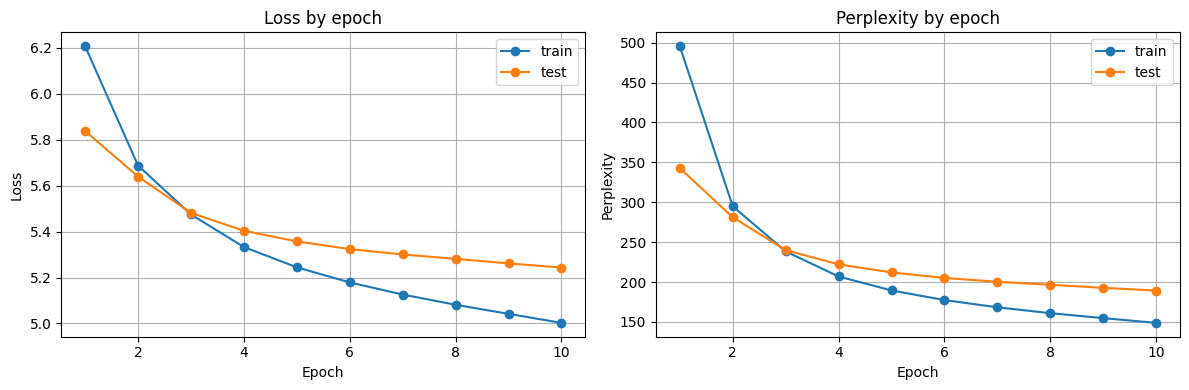

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, len(train_losses) + 1), train_losses, marker="o", label="train")
axes[0].plot(range(1, len(test_losses) + 1), test_losses, marker="o", label="test")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss by epoch")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(range(1, len(train_ppls) + 1), train_ppls, marker="o", label="train")
axes[1].plot(range(1, len(test_ppls) + 1), test_ppls, marker="o", label="test")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Perplexity")
axes[1].set_title("Perplexity by epoch")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

In [69]:
print(generate_text(model, prompt, max_new_tokens=40, method="greedy"))

все счастливые семьи , что он не <unk> , что он не <unk> , что он не <unk> , что он не <unk> , что он не <unk> , что он не <unk> , что он не <unk> , - - - -


In [70]:
print(generate_text(model, prompt, max_new_tokens=40, method="sampling", top_k=10))

все счастливые семьи , как что не могла было не было <unk> , <unk> <unk> ее <unk> . но она было в <unk> и <unk> и <unk> , что это была <unk> , но не было . - - сказал , что я


In [71]:
print(generate_text(model, prompt, max_new_tokens=40, method="sampling", temperature=0.5))

все счастливые семьи . - - - - - - - - - - - - - - - - - я не могу ? - - - - - - - - говорила , - - - - - - - -


In [72]:
print(generate_text(model, prompt, max_new_tokens=40, method="sampling"))

все счастливые семьи . он как une ожидала за по сено ходила на этого . он и вызывали одну невесты , - - но есть мельком по врач такого этого , а каждый встретила . она <unk> , - - как и нет


## Вопросы для анализа

1. **Как меняется loss по эпохам?**
Loss уменьшается, с 1 по 3 эпоху быстрее, потом с 4 по 10 медленнее.

2. **Насколько осмысленным становится текст после обучения?**
Текст получился не особо осмысленным, особенно если использовать method greedy, немного лучше с sampling методами.

3. **Чем greedy decoding отличается от sampling?**
Greedy — модель на каждом шаге берет самое вероятное слово, как в моем случае — модель при генерации инференса попала в локальный максимум и на каждом шаге выбирала одно и то же слово. Sampling — добавляет долю случайности, на каждом шаге есть вероятность выбора не самого популярного слова.

4. **Как влияет temperature?**
При T < 1 модель становится более "консервативной" — выбирает слова с наибольшей вероятностью. При T > 1 — выбирает менее вероятные токены, что позволяет модели выбирать более непредсказуемые варианты при генерации. При T→0 sampling вырождается в greedy, при T→∞ распределение становится равномерным.

5. **Что меняется при top-k?**
Берется топ K самых вероятных слов, остальным словам в словаре присваивается вероятность 0. Среди K распределяется вероятность 1, из усеченного списка случайным образом выбирается слово и так на каждом шаге.

6. **Какие типичные ошибки делает модель?**
- Повторы
- Обрыв фраз
- Неграмматичные продолжения
- Слишком короткая память
- Пропущенные слова (unk) — ограничение словаря, модель не знает слов которых нет в словаре
- Бессмыслицы вроде лишних пробелов и тире